In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
# load in appropriate packages
%load_ext autoreload
%autoreload 2
import pyreadstat
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import re
import xgboost as xgb
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os, sys
from scipy.stats import norm, bernoulli, beta, expon
from ppi_py.datasets import load_dataset
import matplotlib.patheffects as pe
from utils import make_width_coverage_plot, make_width_coverage_split_plot, make_budget_plot
import warnings; warnings.simplefilter('ignore')
import cvxpy as cp
from structuremap.processing import get_smooth_score
from IPython.display import clear_output
from patsy import dmatrix # For generating spline basis
import time
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

### Optimization code

In [2]:
# setup_spline_basis
def setup_spline_basis(uncertainties, num_knots=5, degree=3, name='u'):
    """
    Sets up B-spline basis functions for given uncertainties. 
    """
    if len(uncertainties) == 0:
        return np.zeros((0, 0)), None # Handle empty input
        
    # Ensure enough unique points relative to knots/degree
    unique_uncertainties = np.unique(uncertainties)
    required_unique = degree + 1 
    if len(unique_uncertainties) < required_unique:
         print(f"Warning: Need at least {required_unique} unique uncertainty points for degree {degree} spline, "
               f"found {len(unique_uncertainties)}. Reducing degree or complexity might be needed.")

    if len(unique_uncertainties) < num_knots + 1:
        num_knots = max(0, len(unique_uncertainties) - degree - 1) # Try to leave enough points between knots


    # Define knot locations (e.g., quantiles)
    knot_quantiles = np.linspace(0, 1, num_knots + 2)[1:-1] 
    
    # Handle case where all uncertainties are the same
    if len(unique_uncertainties) == 1:
         knots = np.array([]) # No internal knots
         num_knots = 0 # Force num_knots to 0
         # Use df instead of knots for constant case
         formula = f"bs({name}, df={degree+1}, degree={degree}, include_intercept=True)"
         data = {name: uncertainties}
         try:
              basis_matrix = dmatrix(formula, data, return_type='dataframe')
              return basis_matrix.values, None
         except Exception as e:
             print(f"Patsy error even with df for constant uncertainty: {e}. Returning basic constant basis.")
             # Fallback to a truly constant basis (vector of ones)
             return np.ones((len(uncertainties), 1)), None


    # Proceed with knot calculation for non-constant cases
    if num_knots > 0:
         knots = np.quantile(uncertainties, knot_quantiles)
         knots = np.unique(knots) # Ensure knots are unique
         # Check if knots collapsed or are too close to boundaries
         min_u, max_u = np.min(uncertainties), np.max(uncertainties)
         # Remove knots too close to the boundary? Sometimes helps patsy.
         # knots = knots[(knots > min_u) & (knots < max_u)] 
         if len(knots) < num_knots:
              # print(f"Warning: Number of unique knots reduced to {len(knots)}.")
              pass # Let patsy handle fewer knots
         if len(knots) == 0 and num_knots > 0:
              print("Warning: All internal knots collapsed. Proceeding without internal knots.")
              num_knots = 0 # Update num_knots if they vanished

    else: # num_knots is 0
         knots = np.array([])

    # Create the design matrix using patsy
    # Use bs() for B-splines
    if num_knots > 0:
        formula = f"bs({name}, knots=knots, degree=degree, include_intercept=True)"
    else: # No internal knots, use df
         df = degree + 1 # Number of basis functions for degree d, no internal knots
         formula = f"bs({name}, df={df}, degree={degree}, include_intercept=True)"

    data = {name: uncertainties}
    
    try:
        basis_matrix = dmatrix(formula, data, return_type='dataframe')
    except Exception as e:
         print(f"Patsy error: {e}. Trying simpler df if knots were used.")
         try:
             # Fallback if specific knot creation failed
             df = num_knots + degree + 1 # Total degrees of freedom expected
             formula = f"bs({name}, df={df}, degree={degree}, include_intercept=True)"
             basis_matrix = dmatrix(formula, data, return_type='dataframe')
             knots = None # Knots aren't explicitly defined in this case
         except Exception as e2:
             print(f"Patsy fallback failed: {e2}. Returning basic constant basis.")
             return np.ones((len(uncertainties), 1)), None


    # Check if basis matrix has expected shape
    expected_cols = num_knots + degree + 1 # Intercept is included in the count here
    if basis_matrix.shape[1] == 0 and expected_cols > 0 :
         print(f"Warning: Patsy generated an empty basis matrix ({basis_matrix.shape}). Check inputs/parameters. Returning constant basis.")
         return np.ones((len(uncertainties), 1)), None
         
    return basis_matrix.values, knots # Return as numpy array



In [3]:
def sampling_probs_spline_inv(u1_all, u0_all, b1, b0, mu1, mu0, n_budget, num_knots=5, degree=3, verbose_solver=False):
    """
    Args:
        u1_all (np.ndarray): Individual uncertainty scores for group 1 points.
        u0_all (np.ndarray): Individual uncertainty scores for group 0 points.
        b1 (np.ndarray): individual scores (potentially diff from uncertainty scores) for constructing spline basis for group 1 points.
        b0 (np.ndarray): individual scores ("") for constructing spline basis for group 0 points.
        mu1 (float): Estimated mean for group 1 (used for scaling objective).
        mu0 (float): Estimated mean for group 0 (used for scaling objective).
        n_budget (float): Total expected sample budget.
        num_knots (int): Number of internal knots for the splines.
        degree (int): Degree of the spline polynomials.
        verbose_solver (bool): If True, show detailed solver output.

    Returns:
        tuple: (probs1, probs0, spline_params1, spline_params0)
               probs1 (np.ndarray): Sampling probabilities for group 1 points.
               probs0 (np.ndarray): Sampling probabilities for group 0 points.
               spline_params1 (dict): Info about group 1 spline (coeffs, knots, degree).
               spline_params0 (dict): Info about group 0 spline (coeffs, knots, degree).
        Returns (None, None, None, None) if optimization fails.
    """
    overall_start_time = time.perf_counter()
    n1 = len(u1_all)
    n0 = len(u0_all)

    if n1 == 0 and n0 == 0:
        print("Warning: Both groups are empty.")
        return np.array([]), np.array([]), None, None
    if n_budget <= 0:
         print("Warning: Budget is non-positive. Returning zero probabilities.")
         return np.zeros(n1), np.zeros(n0), None, None

    # --- Setup Spline Basis (Same as before) ---
    B1, knots1 = np.zeros((n1, 0)), None
    B0, knots0 = np.zeros((n0, 0)), None
    n_basis1 = 0
    n_basis0 = 0

    if n1 > 0:
        try:
             #B1, knots1 = setup_spline_basis(u1_all, num_knots, degree, name='u1')
             B1, knots1 = setup_spline_basis(b1, num_knots, degree, name = 'u1')
             n_basis1 = B1.shape[1]
             if n_basis1 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
            print(f"Could not create spline basis for group 1: {e}. Check uncertainty values.")
            n_basis1 = 0 # Ensure it's zero
    if n0 > 0:
        try:
            B0, knots0 = setup_spline_basis(b0, num_knots, degree, name = 'u0')
            #B0, knots0 = setup_spline_basis(u0_all, num_knots, degree, name='u0')
            n_basis0 = B0.shape[1]
            if n_basis0 == 0: raise ValueError("Basis matrix is empty")
        except Exception as e:
             print(f"Could not create spline basis for group 0: {e}. Check uncertainty values.")
             n_basis0 = 0 # Ensure it's zero

    if n_basis1 == 0 and n_basis0 == 0 and (n1 > 0 or n0 > 0):
         print("Error: Could not create spline basis for either group. Cannot optimize.")
         return None, None, None, None

    # --- CVXPY Optimization
    theta1 = cp.Variable(n_basis1, name="theta1") if n_basis1 > 0 else None
    theta0 = cp.Variable(n_basis0, name="theta0") if n_basis0 > 0 else None

    log_x1, log_x0 = None, None
    x1, x0 = None, None
    p1, p0 = None, None

    constraints = []
    objective_terms = []
    budget_terms = []

    # Group 1 calculations
    if n1 > 0 and n_basis1 > 0 and theta1 is not None and mu1 > 0 and mu1 < 1:
        w1 = u1_all / (n1**2 * (mu1**2) * (1 - mu1)**2)
        log_x1 = B1 @ theta1
        x1 = cp.exp(log_x1)
        p1 = cp.exp(-log_x1)
        objective_terms.append(cp.sum(cp.multiply(w1, x1)))
        budget_terms.append(cp.sum(p1))
        #budget_terms.append(-log_x1)
        constraints.append(log_x1 >= 0)
    elif n1 > 0:
         print(f"Warning: Skipping group 1 contributions (n1={n1}, n_basis1={n_basis1}, mu1={mu1})")

    # Group 0 calculations
    if n0 > 0 and n_basis0 > 0 and theta0 is not None and mu0 > 0 and mu0 < 1:
        w0 = u0_all / (n0**2 * (mu0**2) * (1 - mu0)**2)
        log_x0 = B0 @ theta0
        x0 = cp.exp(log_x0)
        p0 = cp.exp(-log_x0)
        objective_terms.append(cp.sum(cp.multiply(w0, x0)))
        budget_terms.append(cp.sum(p0))
        #budget_terms.append(-log_x0)
        constraints.append(log_x0 >= 0)
    elif n0 > 0:
        print(f"Warning: Skipping group 0 contributions (n0={n0}, n_basis0={n_basis0}, mu0={mu0})")

    if not objective_terms:
         print("Error: No valid objective terms could be constructed.")
         return None, None, None, None

    # Objective function: Minimize sum of weighted inverse probabilities (w_i * x_i)
    objective = cp.Minimize(cp.sum(objective_terms))

    # Budget Constraint: sum(p_i) <= n_budget
    if budget_terms: # Only add budget constraint if there are probabilities to sum
        constraints.append(cp.sum(budget_terms) <= n_budget)
        #log_xs = cp.multiply(np.ones(len(budget_terms), budget_terms))
        #constraints.append(cp.log_sum_exp(-cp.hstack(budget_terms)) <= cp.log(n_budget))
    else:
         print("Warning: No variables to constrain budget.")

    problem = cp.Problem(objective, constraints)

    # --- Solve the problem with MOSEK, falling back to ECOS, then SCS ---
    # Define solver priority list
    solver_list = [cp.MOSEK, cp.ECOS, cp.SCS]
    solved = False

    for solver_name in solver_list: # solver_name is 'MOSEK', 'ECOS', or 'SCS'

        #print(f"Attempting to solve with {solver_name}...")
        try:
            # --- Solver Specific Arguments & Options ---
            # Start with common arguments
            solver_kwargs = {
                'verbose': verbose_solver,
                # General tolerance arguments might be added here,
                # but specific ones are often better handled below.
            }

            # --- Configure solver-specific arguments ---

            if solver_name == cp.ECOS: # Or just 'ECOS'
                 # ECOS takes arguments directly
                 solver_kwargs['max_iters'] = 200
                 solver_kwargs['abstol'] = 1e-8 # Example specific tolerances
                 solver_kwargs['reltol'] = 1e-7

            elif solver_name == cp.SCS: # Or just 'SCS'
                 # SCS takes arguments directly
                 solver_kwargs['eps'] = 1e-5 # Example specific tolerance

            # --- Solve ---
            # Unpack the prepared kwargs dictionary. If solver is MOSEK,
            # this will now directly pass MSK_DPAR... arguments.
            #print(f"Passing kwargs to {solver_name}: {solver_kwargs}") # Debug print
            problem.solve(solver=solver_name, **solver_kwargs, mosek_params={"MSK_IPAR_NUM_THREADS": 1})
            final_status = problem.status

            # --- Check Status ---
            # If solved optimally or inaccurately, stop trying other solvers
            if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
                #print(f"{solver_name} finished with status: {problem.status}")
                solved = True
                break # Exit the loop
            else:
                print(f"{solver_name} failed with status: {problem.status}")
                # Continue to the next solver in the list

        except (cp.SolverError, ValueError, ImportError) as e:
             # ImportError can happen if solver seems installed but has runtime issues (e.g., MOSEK license)
            print(f"{solver_name} solver encountered an error: {e}")
            # Continue to the next solver in the list

    if not solved:
        print("All attempted solvers failed to find an optimal or inaccurate solution.")
        # Ensure problem status reflects the failure if loop finishes without success
        if problem.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
             problem.status = "solver_error"


    # --- Check for solution (rest of the code is the same) ---
    overall_end_time = time.perf_counter()
    if problem.status in ["optimal", "optimal_inaccurate"]:
        #print(f"Optimization successful (Final Status: {problem.status}). Objective value: {problem.value}")
        #print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds") # Added total time

        final_probs1 = np.zeros(n1)
        final_probs0 = np.zeros(n0)
        final_theta1 = None
        final_theta0 = None

        # Retrieve results safely (check if variables and .value exist)
        if p1 is not None and theta1 is not None and hasattr(theta1, 'value') and theta1.value is not None:
            final_theta1 = theta1.value
            try:
                 log_x1_opt = B1 @ final_theta1
                 final_probs1 = np.exp(-log_x1_opt)
                 final_probs1 = np.clip(final_probs1, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 1: {calc_e}")
                 final_probs1 = np.zeros(n1) # Fallback
                 final_theta1 = None # Invalidate theta if calc failed

        if p0 is not None and theta0 is not None and hasattr(theta0, 'value') and theta0.value is not None:
            final_theta0 = theta0.value
            try:
                log_x0_opt = B0 @ final_theta0
                final_probs0 = np.exp(-log_x0_opt)
                final_probs0 = np.clip(final_probs0, 0, 1)
            except Exception as calc_e:
                 print(f"Error calculating final probabilities for group 0: {calc_e}")
                 final_probs0 = np.zeros(n0) # Fallback
                 final_theta0 = None # Invalidate theta if calc failed

        # Store spline parameters
        spline_params1 = {'coeffs': final_theta1, 'knots': knots1, 'degree': degree, 'n_basis': n_basis1} if n_basis1 > 0 and final_theta1 is not None else None
        spline_params0 = {'coeffs': final_theta0, 'knots': knots0, 'degree': degree, 'n_basis': n_basis0} if n_basis0 > 0 and final_theta0 is not None else None

        # Sanity check budget constraint
        actual_expected_samples = np.sum(final_probs1) + np.sum(final_probs0)
        # Use a slightly larger tolerance for feasibility checks after solve
        # Check against 1% deviation or a small absolute value
        upper_bound = max(n_budget * 1.01, n_budget + 1e-4)
        lower_bound = min(n_budget * 0.99, n_budget - 1e-4)

        if actual_expected_samples > upper_bound:
             print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"significantly exceed budget ({n_budget:.4f}). Status: {problem.status}")
        # Check for underutilization only if budget likely should have been tight (objective > 0)
        elif actual_expected_samples < lower_bound and abs(problem.value) > 1e-6:
              print(f"Warning: Calculated expected samples ({actual_expected_samples:.4f}) "
                   f"is significantly under budget ({n_budget:.4f}). Solution might be suboptimal if budget wasn't tight.")


        return final_probs1, final_probs0, spline_params1, spline_params0

    else:
        print(f"Problem not solved optimally. Final Status: {problem.status}")
        print(f"Total Time: {overall_end_time - overall_start_time:.4f} seconds")
        return None, None, None, None

### Helper functions for analysis

In [4]:
def opt_mean_tuning(Y, Yhat, weights, sampling_ratio): #lambda star is sum of Y * f where f is Yhat * weights * sampling ratio
    return np.clip(np.mean(Y*Yhat*weights*sampling_ratio)/np.mean(Yhat**2*sampling_ratio), 0, 1)

def odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights0, weights1, alpha, lhat0=None, lhat1=None):
    n0 = Y0.shape[0]
    n1 = Y1.shape[0]    
    mu0_hat = np.mean(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*weights0)
    mu1_hat = np.mean(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*weights1)
    pointest_log = np.log(mu1_hat/(1-mu1_hat)) - np.log(mu0_hat/(1-mu0_hat))
    var_mu0_hat = np.var(lhat0*Yhat0 + (Y0 - lhat0*Yhat0)*weights0)
    var_mu1_hat = np.var(lhat1*Yhat1 + (Y1 - lhat1*Yhat1)*weights1)
    var0 = var_mu0_hat/((mu0_hat*(1-mu0_hat))**2)
    var1 = var_mu1_hat/((mu1_hat*(1-mu1_hat))**2)
    p0 = n0/(n0+n1)
    p1 = n1/(n0+n1)
    var = 1/p0*var0 + 1/p1*var1
    width_log = norm.ppf(1-alpha/2)*np.sqrt(var/(n0+n1))
    return np.exp(pointest_log - width_log), np.exp(pointest_log + width_log), var

In [5]:
def train_tree(X, Y, eta=0.001, max_depth=3, objective='reg:squarederror', boost_rounds=2000):
    dtrain = xgb.DMatrix(X, label=Y)
    tree = xgb.train({'eta': eta, 'max_depth': max_depth, 'objective': objective}, dtrain, boost_rounds)
    return tree


def tree_predict(tree, X):
    return tree.predict(xgb.DMatrix(X))

### Plotting code

In [6]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

In [7]:
def plot_eff_sample_size(df, plot_title):
    df = df[df.estimator != "LLM only"]
    ylab = "$n_{\mathrm{effective}}$"
    xlab = "$n_{\mathrm{human}}$"

    desired_order = ["active", "active + tuning", 
                     "spline", "spline + tuning", 
                     "uniform", "classical"]

    color_map = {"active": 'tab:orange', 
                 "active + tuning": 'tab:orange',
                 "spline": 'tab:green',
                 "spline + tuning": 'tab:green',
                 "uniform": 'tab:blue',
                 "classical": 'tab:purple'}
    
    linestyle_map = {
        "active": "-",
        "active + tuning": "--",   # dashed
        "spline": "-",
        "spline + tuning": "--",
        "uniform": "-",
        "classical": "-"
    }

    markers = ["o", "o", "s", "s", "D", "X"]  # Different marker shapes
    sns.set_theme(font_scale=2.2, style='white', rc={'lines.linewidth': 3})
    df_mean = df.groupby([xlab, 'estimator'])[ylab].mean().reset_index()
    fig, ax = plt.subplots(figsize=(7, 8))

    for i, est in enumerate(desired_order):
        subset = df_mean[df_mean['estimator'] == est]
        ax.plot(subset[xlab], subset[ylab],
                label=est,
                color=color_map[est],
                linestyle=linestyle_map[est],
                #linestyle='-' if dashes_map[est] == "" else None,
                #dashes=None if dashes_map[est] == "" else dashes_map[est],
                marker=markers[i],
                markersize=10,
                linewidth=2)
        # ax.fill_between(subset[xlab], subset_lower[ylab], subset_upper[ylab],
        #                 color=color_map[est],
        #                 alpha=0.2)

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    sns.despine(top=True, right=True)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend().remove()

    #ax.set_yticks(np.arange(100, 500+1, 100))

    # making a fake legend
    
    
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight')
    plt.show()
    # sns.lineplot(data=df_mean, x=xlab, y=ylab, hue='estimator', hue_order=desired_order, ax=ax,
    #              style='estimator', markers=markers, linewidth=2, alpha=0.7, legend=False)
    # sns.scatterplot(data=df_mean, x=xlab, y=ylab, hue='estimator', hue_order=desired_order, ax=ax, s=70, alpha=0.7, edgecolor='black', style='estimator', markers=markers)
    # ax.legend().remove()
    # ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    # sns.despine(top=True, right=True)
    # plt.tight_layout()
    # plt.savefig(plot_title, bbox_inches='tight')
    # plt.show()

In [8]:
def plot_eff_sample_size(df, plot_title):
    df = df[df.estimator != "LLM only"]
    ylab = "$n_{\mathrm{effective}}$"
    xlab = "$n_{\mathrm{human}}$"

    desired_order = ["active", "active+",
                     "spline", "spline+", 
                     "uniform", "classical"]

    color_map = {"active": 'tab:orange', 
                 "active+": 'tab:orange',
                 "spline": 'tab:green',
                 "spline+": 'tab:green',
                 "uniform": 'tab:blue',
                 "classical": 'tab:purple'}
    
    linestyle_map = {
        "active": "-",
        "active+": "--",   # dashed
        "spline": "-",
        "spline+": "--",
        "uniform": "-",
        "classical": "-"
    }

    markers = ["o", "o", "s", "s", "D", "X"]  # Different marker shapes
    sns.set_theme(font_scale=2.2, style='white', rc={'lines.linewidth': 3})
    df_mean = df.groupby([xlab, 'estimator'])[ylab].mean().reset_index()
    fig, ax = plt.subplots(figsize=(7, 8))

    for i, est in enumerate(desired_order):
        subset = df_mean[df_mean['estimator'] == est]
        ax.plot(subset[xlab], subset[ylab],
                label=est,
                color=color_map[est],
                linestyle=linestyle_map[est],
                #linestyle='-' if dashes_map[est] == "" else None,
                #dashes=None if dashes_map[est] == "" else dashes_map[est],
                marker=markers[i],
                markersize=10,
                linewidth=2)
        # ax.fill_between(subset[xlab], subset_lower[ylab], subset_upper[ylab],
        #                 color=color_map[est],
        #                 alpha=0.2)

    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    sns.despine(top=True, right=True)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend().remove()

    #ax.set_yticks(np.arange(100, 500+1, 100))

    # making a fake legend
    
    
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight')
    plt.show()
    # sns.lineplot(data=df_mean, x=xlab, y=ylab, hue='estimator', hue_order=desired_order, ax=ax,
    #              style='estimator', markers=markers, linewidth=2, alpha=0.7, legend=False)
    # sns.scatterplot(data=df_mean, x=xlab, y=ylab, hue='estimator', hue_order=desired_order, ax=ax, s=70, alpha=0.7, edgecolor='black', style='estimator', markers=markers)
    # ax.legend().remove()
    # ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    # sns.despine(top=True, right=True)
    # plt.tight_layout()
    # plt.savefig(plot_title, bbox_inches='tight')
    # plt.show()

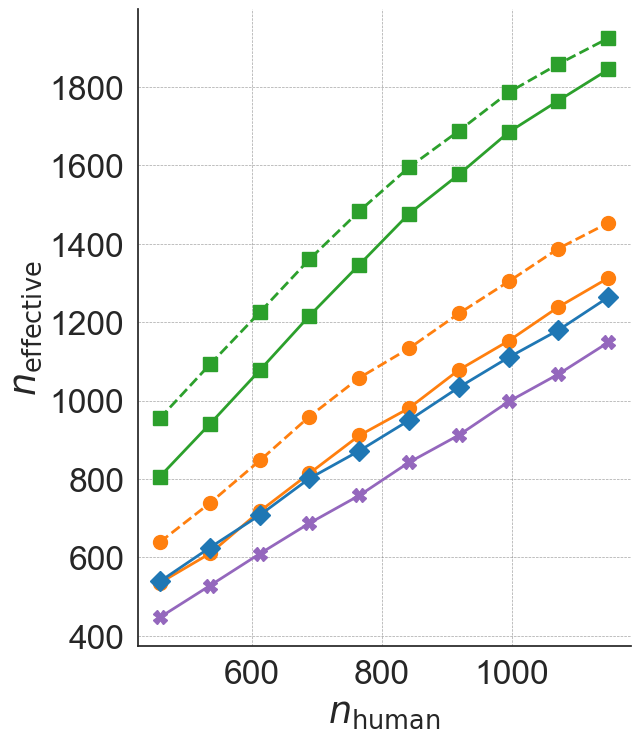

In [111]:
plot_eff_sample_size(df_all, "plots/seqstance_ESS.pdf")

In [9]:
def plot_coverage(df, alpha, plot_title):
    # ────────────────────────────────────
    # 1.  keep six estimators of interest
    # ────────────────────────────────────
    desired_order = ["active", "active+",
                     "spline", "spline+",
                     "uniform", "classical"]
    df = df[df.estimator.isin(desired_order)].copy()

    # optional: make "LLM only" flat (kept for completeness; remove if unused)
    if "LLM only" in df.estimator.unique():
        llm_only_mean = df.loc[df.estimator == "LLM only", "coverage"].mean()
        df.loc[df.estimator == "LLM only", "coverage"] = llm_only_mean

    # ────────────────────────────────────
    # 2.  aesthetic maps
    # ────────────────────────────────────
    color_map = {"active":           'tab:orange',
                 "active + tuning":  'tab:orange',
                 "spline":           'tab:green',
                 "spline + tuning":  'tab:green',
                 "uniform":          'tab:blue',
                 "classical":        'tab:purple'}

    linestyle_map = {"active": "--",           # all dashed in screenshot style
                     "active + tuning": ":",
                     "spline": "--",
                     "spline + tuning": ":",
                     "uniform": "--",
                     "classical": "--"}

    marker_map = {"active": "o", "active + tuning": "o",
                  "spline": "s", "spline + tuning": "s",
                  "uniform": "D", "classical": "X"}

    # ────────────────────────────────────
    # 3.  prepare data (mean over trials)
    # ────────────────────────────────────
    xlab = r"$n_{\mathrm{human}}$"
    ylab = "coverage"

    df_mean = (df.groupby([xlab, "estimator"], observed=True)[ylab]
                 .mean()
                 .reset_index())

    # ────────────────────────────────────
    # 4.  plot
    # ────────────────────────────────────
    sns.set_theme(font_scale=2.2,
                  style="white",
                  rc={"lines.linewidth": 3, "axes.linewidth": 2})

    fig, ax = plt.subplots(figsize=(7, 8))

    for est in desired_order:
        sub = df_mean[df_mean["estimator"] == est]
        if sub.empty:
            continue

        # dashed trend line
        ax.plot(sub[xlab], sub[ylab],
                label=est,
                color=color_map[est],
                linestyle=linestyle_map[est],
                linewidth=2)

        # filled marker with thin black edge (no white halo)
        ax.scatter(sub[xlab], sub[ylab],
                   marker=marker_map[est],
                   s=120,                    # marker size
                   color=color_map[est],
                   edgecolor='none',
                   zorder=3)

    # nominal line at 1-alpha
    ax.axhline(1 - alpha, color="#888888",
               linestyle="--", linewidth=1, alpha=0.7, zorder=1)

    # axes, grid, ticks
    ax.grid(True, which='both', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.7)
    sns.despine(ax=ax, top=True, right=True)

    ax.set_xlabel(xlab, fontstyle='italic')
    ax.set_ylabel(ylab, fontstyle='italic')
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.tick_params(axis='both', direction='in', width=2, length=6)

    # no legend box (comment out to show)
    if ax.get_legend():
        ax.legend().remove()

    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()

In [10]:
def plot_intervals(
        df,
        true_val,
        num_trials,
        estimand_title,
        plot_title,
        n_ind=-1,          # which n_human slice (−1 == last / largest)
        num_ints=5,        # intervals per estimator to show
        bar_height=0.8,    # in y–grid units (≤1.0)
        gap=0.3            # vertical gap between colour groups
):
    # ─── 1. estimator order & style maps ─────────────────────────────────
    methods = ["active", "active + tuning",
               "spline", "spline + tuning",
               "uniform", "classical"]

    colours = {"active":           "#F29F5B",   # orange
               "active + tuning":  "#F29F5B",
               "spline":           "#6EAD61",   # green
               "spline + tuning":  "#6EAD61",
               "uniform":          "#5D8DB9",   # blue
               "classical":        "#9B59B6"}   # purple

    hatches = {"active": "",
               "active + tuning": "///",
               "spline": "",
               "spline + tuning": "///",
               "uniform": "",
               "classical": ""}

    # ─── 2. choose n_human slice & sample rows ───────────────────────────
    ns = np.sort(df["$n_{\\mathrm{human}}$"].unique())
    n_human = ns[n_ind]

    # randomly choose the row positions once, reuse across estimators
    rng_rows  = np.random.choice(num_trials, num_ints, replace=False)

    # build a list of (estimator, lo, hi) in desired plotting order
    rows_to_plot = []
    for est in methods:
        subset = df[(df.estimator == est) & (df["$n_{\\mathrm{human}}$"] == n_human)]
        if len(subset) == 0:
            continue                     # skip if estimator absent
        subset = subset.iloc[rng_rows % len(subset)]  # safe wrap
        for _, r in subset.iterrows():
            rows_to_plot.append((est, r.lb, r.ub))

    # reverse so first interval appears at top
    rows_to_plot = rows_to_plot[::-1]

    # ─── 3. figure size: 0.45″ per interval row works well ───────────────
    fig_h = max(4, 0.45 * len(rows_to_plot))
    sns.set_theme(font_scale=2.2, style='white', rc={'axes.linewidth': 2})
    fig, ax = plt.subplots(figsize=(7, fig_h))

    # vertical reference
    ax.axvline(true_val, color='gray', linestyle='--', linewidth=1)
    xmax = 0
    xmin = 2
    # ─── 4. add rectangles, one y–unit per interval ──────────────────────
    for y, (est, lo, hi) in enumerate(rows_to_plot):
        rect = mpatches.Rectangle(
            (lo, y - bar_height/2),          # (x-left, y-bottom)
            hi - lo,                         # width
            bar_height,                      # height
            facecolor=lighten_color(colours[est], 0.35),
            edgecolor='black',
            linewidth=1,
            hatch=hatches[est],
            zorder=3
        )
        ax.add_patch(rect)
        xmax = max(xmax, hi)
        xmin = min(xmin, lo)

    # ─── 5. tidy up axes ─────────────────────────────────────────────────
    ymax = len(rows_to_plot) - 0.5
    ymin = -0.5
    ax.set_ylim(ymax + gap, ymin)           # invert y so first row at top
    ax.set_yticks([])

    # x-limits: add 5 % padding either side
    #xmin = df[["lb", "ub"]].min().min()
    #xmax = df[["lb", "ub"]].max().max()
    pad  = 0.05 * (xmax - xmin)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_xlabel(estimand_title, fontstyle='italic')
    sns.despine(ax=ax, top=True, right=True, left=True)
    plt.tight_layout()
    plt.savefig(plot_title, bbox_inches='tight', dpi=300)
    plt.show()


### Loading data

In [11]:
data = pd.read_csv('data/stance_dataset.csv')
data = data.sample(frac=1).reset_index(drop=True) # shuffle data

affirming_devices = ['uncover', 'realize', 'know', 'understand', 'learn', 'concede',
'remember', 'recall', 'discover', 'show', 'reveal', 'see',
'forget', 'find', 'point out', 'indicate', 'acknowledge',
'admit', 'realize', 'notice', 'certify', 'verify', 'corroborate', 'affirm', 'confirm', 'agree', 'conclude',
'proven', 'settled', 'conclusive', 'definitive',
'famed', 'unequivocal', 'skilful', 'notable', 'strong', 'famous', 'Nobel', 'skillful',
'Nobelist', 'Nobel Laureate', 'Nobel prize winner',
'Nobel prize winning', 'prize winning', 'award',
'winning', 'distinguished', 'well-grounded', 'esteemed', 'proficient', 'key', 'evidence', 'noted', 'top',
'preeminent', 'breakthrough', 'significant', 'intelligent', 'of import', 'celebrated', 'novel', 'recent',
'major', 'landmark', 'important', 'distinguished',
'renowned', 'peer-reviewed', 'expert', 'leading',
'thousand', '1000', 'hundred', '100', 'unanimous', 'diverse',
'substantial', 'many', 'multiple', 'dozen', 'numerous']

escaped_terms = [re.escape(term) for term in affirming_devices]
pattern = '|'.join(escaped_terms)
data['contains_affirming_device'] = data['sentence'].str.contains(pattern, case=False, regex=True)

In [12]:
Yhat_string = data["label_gpt4o"].to_numpy()
confidence = data["confidence_in_prediction_gpt-4o"].to_numpy()
nan_indices = list(np.where(pd.isna(confidence))[0]) + list(np.where(pd.isna(Yhat_string))[0])
good_indices = list(set(range(len(data))) - set(nan_indices))
confidence = confidence[good_indices]
device = data['contains_affirming_device'].to_numpy()[good_indices]
Yhat_string = Yhat_string[good_indices]
Y_string = data["MACE_pred"].to_numpy()[good_indices]
n = len(Yhat_string)
dict = {"A" : 1, "B" : 0, "C" : 0, "agrees": 1, "neutral" : 0, "disagrees": 0}
Yhat = np.array([dict[Yhat_string[i]] for i in range(n)])
Y = np.array([dict[Y_string[i]] for i in range(n)])
confidence = confidence.reshape(len(confidence),1)

In [13]:
Y1 = Y[device]
Y0 = Y[~device]
Yhat1 = Yhat[device]
Yhat0 = Yhat[~device]
confidence1 = confidence[device]
confidence0 = confidence[~device]
n0 = len(Y0)
n1 = len(Y1)

In [15]:
# use 200 as "train" data (taken proportionally)
#np.random.seed(614)
#n1_tr = round(200 * n1/(n0 + n1))
#n1_tr = 100
#Y1_train, Y1_test, Yhat1_train, Yhat1_test, confidence1_train, confidence1_test = train_test_split(Y1, Yhat1, confidence1, train_size = n1_tr)
#Y0_train, Y0_test, Yhat0_train, Yhat0_test, confidence0_train, confidence0_test = train_test_split(Y0, Yhat0, confidence0, train_size = 200 - n1_tr)

In [26]:
# confidence_test = np.vstack([confidence1_test, confidence0_test]).reshape(-1, 1)
# Yhat_test = np.concatenate([Yhat1_test, Yhat0_test]).reshape(-1, 1)
# Y_test = np.concatenate([Y1_test, Y0_test]).reshape(-1, 1)
# n0 = len(Y0_test)
# n1 = len(Y1_test)
# group_label = np.concatenate([np.ones(n1,  dtype=int), np.zeros(n0, dtype=int)])
# rng   = np.random.default_rng(seed=614)
# order = rng.permutation(n1 + n0)
# confidence_test = confidence_test[order]
# Yhat_test = Yhat_test[order]
# Y_test = Y_test[order]
# group_label = group_label[order]
# group1_idx = np.where(group_label == 1)[0]
# group0_idx = np.where(group_label == 0)[0]
# n0 = len(Y0_test)
# n1 = len(Y1_test)

In [16]:
mu0 = Y0.mean()
mu1 = Y1.mean()
true_odds_ratio = (mu1 / (1 - mu1)) / (mu0 / (1 - mu0))
true_var = (1/np.sum(Y0==0) + 1/np.sum(Y0==1) + 1/np.sum(Y1==0) + 1/np.sum(Y1==1))*n
n1, n0 = len(Y0), len(Y1)

### Analysis

In [21]:
# def opt_mean_tuning(Y, Yhat, weights, sampling_ratio): #lambda star is sum of Y * f where f is Yhat * weights * sampling ratio
#     return np.clip(np.mean(Y*Yhat*weights*sampling_ratio)/np.mean(Yhat**2*sampling_ratio), 0, 1)

def opt_mean_tuning(Y, Yhat, weights, sampling_ratio):
    return np.clip(np.mean((Y - np.mean(Y)) * (Yhat - np.mean(Yhat)) * weights * sampling_ratio)/np.mean((Yhat - np.mean(Yhat))**2 * sampling_ratio), 0, 1)

In [ ]:
# test how the opt_mean_tuning works now with the covariance rather than just first product moment

In [17]:
np.cov(Y1, Yhat1)

array([[0.22388204, 0.1587429 ],
       [0.1587429 , 0.25042226]])

In [19]:
np.mean((Y1 - np.mean(Y1)) * (Yhat1 - np.mean(Yhat1)))

0.15840225460037946

In [ ]:
np.random.seed(614)
alpha = 0.1  # desired error level for confidence interval
#fracs_human = np.linspace(0.2, 0.5, 10)  # overall sampling budget
fracs_human = [0.2]
#num_trials = 50
num_trials = 1

num_methods = 6
temp_df = pd.DataFrame({
    "lb": np.zeros(num_methods),
    "ub": np.zeros(num_methods),
    "interval width": np.zeros(num_methods),
    "coverage": np.zeros(num_methods),
    "estimator": [""] * num_methods,
    "$n_{\mathrm{human}}$": np.zeros(num_methods),
    "$n_{\mathrm{effective}}$": np.zeros(num_methods)
})

burnin_steps = 50  # we collect the first burnin_steps points to initialize sampling rule
retrain_steps = 100  # every retrain_steps we retrain mapping from confidence to sampling probability
tau = 0.1  # parameter for mixing with uniform sampling for increased stability

results = []

for j in tqdm(range(len(fracs_human))):
    frac_human = fracs_human[j]
    frac_human_adjusted = (frac_human*n - burnin_steps)/(n - burnin_steps) # remove burnin_steps samples from available budget for both classes
    mu1_init, mu0_init = (Y1[:burnin_steps]).mean(), (Y0[:burnin_steps]).mean()
    #weights_init = np.concatenate([np.ones(burnin_steps), np.zeros(n - burnin_steps)])
    weights_init = np.ones(burnin_steps)
    sampling_ratio_init = np.ones(burnin_steps)
    lambda_1 = opt_mean_tuning(Y1[:burnin_steps], Yhat1[:burnin_steps], weights_init, sampling_ratio_init)
    lambda_0 = opt_mean_tuning(Y0[:burnin_steps], Yhat0[:burnin_steps], weights_init, sampling_ratio_init)
    #lambda_1 = np.mean((Y1[:burnin_steps] - Y1[:burnin_steps].mean()) * (Yhat1[:burnin_steps] - Yhat1[:burnin_steps].mean())) / np.var(Yhat1[:burnin_steps])
    #lambda_0 = np.mean((Y0[:burnin_steps] - Y0[:burnin_steps].mean()) * (Yhat0[:burnin_steps] - Yhat0[:burnin_steps].mean())) / np.var(Yhat0[:burnin_steps])
    for i in tqdm(range(num_trials)):
        tree = train_tree(confidence[:burnin_steps], ((Y - Yhat)[:burnin_steps])**2)
        uncertainties_active = np.sqrt(tree_predict(tree, confidence))
        #uncertainties_spline = uncertainties_active.copy()
        #uncertainty1 = np.sqrt(tree_predict(tree, confidence1_test))
        #uncertainty0 = np.sqrt(tree_predict(tree, confidence0_test))
        #uncertainty = np.concatenate([uncertainty1, uncertainty0])
        avg_uncertainty = np.mean(uncertainties_active)
        u1, u0 = uncertainties_active[device], uncertainties_active[~device]

        # need to get probabilities for spline version:
        p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
            u1, u0, u1, u0, mu1_init, mu0_init, (n - burnin_steps) * frac_human_adjusted, num_knots=5, degree=3)
        prob_spline = np.zeros(n)
        prob_spline[device], prob_spline[~device] = p1_spline, p0_spline
        weights_active = np.zeros(n)
        weights_spline = np.zeros(n)
        sampling_ratio = np.zeros(n)
        sampling_ratio_spline = np.zeros(n)
        weights_active[:burnin_steps] = 1 # will label the first burnin_steps 
        weights_spline[:burnin_steps] = 1 # will label the first burnin_steps
        
        for t in range(burnin_steps, n):
            if ((t-burnin_steps) % retrain_steps == 0):
                # re-train for active and spline
                obs_inds = np.where(weights_active)
                obs_inds_spline = np.where(weights_spline)
                tree_active = train_tree(confidence[obs_inds], ((Y - Yhat)[obs_inds])**2)
                tree_spline = train_tree(confidence[obs_inds_spline], ((Y - Yhat)[obs_inds_spline])**2)
                uncertainties_active = np.sqrt(tree_predict(tree_active, confidence))
                avg_uncertainty = np.mean(uncertainties_active)

                uncertainties_spline = np.sqrt(tree_predict(tree_spline, confidence))
                u1, u0 = uncertainties_spline[device], uncertainties_spline[~device]
                p1_spline, p0_spline, params1_inv, params0_inv = sampling_probs_spline_inv(
                    u1, u0, u1, u0, mu1_init, mu0_init, (n - burnin_steps) * frac_human_adjusted, num_knots=5, degree=3)
                prob_spline[device], prob_spline[~device] = p1_spline, p0_spline
                
            # for active
            sampling_prob = uncertainties_active[t]/avg_uncertainty*frac_human_adjusted
            sampling_prob = np.clip((1-tau)*sampling_prob + tau*frac_human_adjusted, 0, 1)
            sampling_ratio[t] = (1-sampling_prob)/sampling_prob
            weights_active[t] = bernoulli.rvs(sampling_prob)/sampling_prob

            # for spline
            sampling_prob_spline = prob_spline[t]
            sampling_ratio_spline[t] = (1-sampling_prob_spline)/sampling_prob_spline
            weights_spline[t] = bernoulli.rvs(sampling_prob_spline)/sampling_prob_spline
            
        weights_active0 = weights_active[~device]
        weights_active1 = weights_active[device]
        weights_spline0 = weights_spline[~device]
        weights_spline1 = weights_spline[device]
        sampling_ratio0 = sampling_ratio[~device]
        sampling_ratio1 = sampling_ratio[device]
        sampling_ratio_spline0 = sampling_ratio_spline[~device]
        sampling_ratio_spline1 = sampling_ratio_spline[device]

        lam0 = opt_mean_tuning(Y0, Yhat0, weights_active0, sampling_ratio0)
        lam1 = opt_mean_tuning(Y1, Yhat1, weights_active1, sampling_ratio1)
        l, u, varhat = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_active0, weights_active1, alpha, lhat0=1, lhat1=1)
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[0] = l, u, u-l, coverage, "active", int(n*frac_human), (true_var/varhat)*n

        l, u, varhat = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_active0, weights_active1, alpha, lhat0=lam0, lhat1=lam1)
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[1] = l, u, u-l, coverage, "active+", int(n*frac_human), (true_var/varhat)*n

        lam0_spline = opt_mean_tuning(Y0, Yhat0, weights_spline0, sampling_ratio_spline0)
        lam1_spline = opt_mean_tuning(Y1, Yhat1, weights_spline1, sampling_ratio_spline1)
        l, u, varhat = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_spline0, weights_spline1, alpha, lhat0=1, lhat1=1)
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[2] = l, u, u-l, coverage, "spline", int(n*frac_human), (true_var/varhat)*n
        l, u, varhat = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, weights_spline0, weights_spline1, alpha, lhat0=lam0_spline, lhat1=lam1_spline)
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[3] = l, u, u-l, coverage, "spline+", int(n*frac_human), (true_var/varhat)*n

        xi_unif0 = bernoulli.rvs([frac_human] * n0)
        xi_unif1 = bernoulli.rvs([frac_human] * n1)
        l, u, varhat = odds_ratio_ci(Y0, Yhat0, Y1, Yhat1, xi_unif0/frac_human, xi_unif1/frac_human, alpha, lhat0=1, lhat1=1)
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[4] = l, u, u-l, coverage, "uniform", int(n*frac_human), (true_var/varhat)*n
        
        mu0 = Y0[np.where(xi_unif0)].mean()
        mu1 = Y1[np.where(xi_unif1)].mean()
        odds_ratio_est = np.log((mu1 / (1 - mu1)) / (mu0 / (1 - mu0)))
        varhat = (1/np.sum(Y0[np.where(xi_unif0)]==0) + 1/np.sum(Y0[np.where(xi_unif0)]==1) + 1/np.sum(Y1[np.where(xi_unif1)]==0) + 1/np.sum(Y1[np.where(xi_unif1)]==1))
        l = np.exp(odds_ratio_est - norm.ppf(1-alpha/2)*np.sqrt(varhat))
        u = np.exp(odds_ratio_est + norm.ppf(1-alpha/2)*np.sqrt(varhat))
        coverage = (true_odds_ratio >= l)*(true_odds_ratio <= u)
        temp_df.loc[5] = l, u, u-l, coverage, "classical", int(n*frac_human), (true_var/varhat)
        
        results += [temp_df.copy()]
df = pd.concat(results,ignore_index=True)
df["coverage"] = df["coverage"].astype(bool)

  0%|          | 0/1 [00:31<?, ?it/s]


KeyboardInterrupt: 

### Stitch the results together

In [94]:
import pathlib
import re
import pandas as pd

# ── 1. file discovery ──────────────────────────────────────────────────────────
log_dir   = pathlib.Path("logs")
pattern   = re.compile(
    r"frac-human=(?P<frac>[0-9.]+)_num-trial=(?P<trial>\d+)\.csv$"
)

frames = []
for p in log_dir.glob("*.csv"):
    m = pattern.match(p.name)
    if m is None:
        continue                          # skip files that don’t match the pattern

    # Accept both "0.2" and "0.200000000000…" as 0.2, allowing tiny FP noise
    # frac_val = float(m.group("frac"))
    # if abs(frac_val - 0.2) > 1e-12:
    #     continue                          # not the frac‑human we want

    trial_num = int(m.group("trial"))

    # ── 2. read & annotate ─────────────────────────────────────────────────────
    df = pd.read_csv(p)
    df["num_trial"] = trial_num
    frames.append(df)

# ── 3. combine ────────────────────────────────────────────────────────────────
if not frames:
    raise ValueError("No files with frac‑human = 0.2 were found in logs/")

df_all = pd.concat(frames, ignore_index=True)
print(f"{len(frames)} files concatenated → shape {df_all.shape}")


976 files concatenated → shape (5856, 8)


In [113]:
df_all.to_csv('stance_sequential_results_old.csv', index = False)

In [93]:
import pathlib, re, pandas as pd, time, os, sys

log_dir  = pathlib.Path("logs")
pattern  = re.compile(r"frac-human=(?P<frac>[0-9.]+)_num-trial=(?P<trial>\d+)\.csv$")

good_frames = []
bad_files   = []

for p in log_dir.glob("*.csv"):
    m = pattern.match(p.name)
    if m is None:
        continue                         # skip odd files

    trial_num = int(m.group("trial"))
    sys.stdout.write(f"· reading {p.name} … "); sys.stdout.flush()

    try:
        df = pd.read_csv(p)
        df["num_trial"] = trial_num
        good_frames.append(df)
        print("✓")
    except Exception as e:
        bad_files.append((p, e))
        print(f"✗  ({e.__class__.__name__}: {e})")

print(f"\n{len(good_frames)} files read OK, {len(bad_files)} failed.")
if bad_files:
    print("Failed files:")
    for p, e in bad_files:
        print(f"  {p}  →  {e}")


· reading frac-human=0.5_num-trial=49.csv … ✓
· reading frac-human=0.5_num-trial=75.csv … ✓
· reading frac-human=0.5_num-trial=61.csv … ✓
· reading frac-human=0.4666666666666667_num-trial=22.csv … ✓
· reading frac-human=0.4666666666666667_num-trial=36.csv … ✓
· reading frac-human=0.4_num-trial=17.csv … ✓
· reading frac-human=0.23333333333333334_num-trial=66.csv … ✓
· reading frac-human=0.30000000000000004_num-trial=52.csv … ✓
· reading frac-human=0.33333333333333337_num-trial=17.csv … ✓
· reading frac-human=0.5_num-trial=6.csv … ✓
· reading frac-human=0.23333333333333334_num-trial=72.csv … ✗  (TimeoutError: [Errno 60] Operation timed out)
· reading frac-human=0.30000000000000004_num-trial=46.csv … ✓
· reading frac-human=0.2_num-trial=2.csv … ✓
· reading frac-human=0.30000000000000004_num-trial=91.csv … ✓
· reading frac-human=0.30000000000000004_num-trial=85.csv … ✓
· reading frac-human=0.23333333333333334_num-trial=99.csv … ✓
· reading frac-human=0.26666666666666666_num-trial=58.csv … 

In [67]:
for csv_path in DATA_DIR.glob("frac-human=*_num-trial=*.csv"):
    print(csv_path, csv_path.exists(), csv_path.stat().st_size)

logs/frac-human=0.4666666666666667_num-trial=22.csv True 663
logs/frac-human=0.4666666666666667_num-trial=36.csv True 665
logs/frac-human=0.4_num-trial=17.csv True 653
logs/frac-human=0.33333333333333337_num-trial=17.csv True 651
logs/frac-human=0.5_num-trial=6.csv True 663
logs/frac-human=0.2_num-trial=2.csv True 646
logs/frac-human=0.4666666666666667_num-trial=8.csv True 660
logs/frac-human=0.43333333333333335_num-trial=30.csv True 654
logs/frac-human=0.33333333333333337_num-trial=1.csv True 652
logs/frac-human=0.43333333333333335_num-trial=24.csv True 658
logs/frac-human=0.43333333333333335_num-trial=18.csv True 654
logs/frac-human=0.43333333333333335_num-trial=19.csv True 653
logs/frac-human=0.43333333333333335_num-trial=25.csv True 654
logs/frac-human=0.33333333333333337_num-trial=0.csv True 652
logs/frac-human=0.43333333333333335_num-trial=31.csv True 652
logs/frac-human=0.4666666666666667_num-trial=9.csv True 663
logs/frac-human=0.2_num-trial=3.csv True 651
logs/frac-human=0.5_n

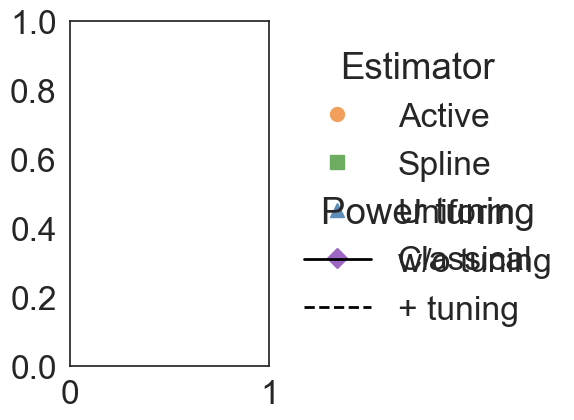

In [108]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots()

# … plotting code for your six series …

# ── 1. handles for the *methods*  ─────────────────────────
method_handles = [
    Line2D([], [], marker='o', color='#F29F5B', lw=0, markersize = 10,  label='Active'),
    Line2D([], [], marker='s', color='#6EAD61', lw=0, markersize = 10, label='Spline'),
    Line2D([], [], marker='^', color='#5D8DB9', lw=0, markersize = 10, label='Uniform'),
    Line2D([], [], marker='D', color='#9C66C2', lw=0, markersize = 10, label='Classical'),
]

# ── 2. handles for the *tuning* line styles  ──────────────
style_handles = [
    Line2D([], [], color='black', lw=2, linestyle='-',  label='w/o tuning'),
    Line2D([], [], color='black', lw=2, linestyle='--', label='+ tuning'),
]

# ── 3. add the two legends  ───────────────────────────────
first = ax.legend(handles=method_handles,
                  loc='upper left', bbox_to_anchor=(1.02, 1),
                  title='Estimator', frameon=False)

second = ax.legend(handles=style_handles,
                   loc='upper left', bbox_to_anchor=(1.02, 0.58),
                   title='Power tuning', frameon=False)

ax.add_artist(first)   # keep the first legend when the second is added
plt.tight_layout()
plt.savefig("legend.pdf", bbox_inches='tight')
plt.show()




In [70]:
from pathlib import Path

DATA_DIR  = Path("logs")
trial_pat = re.compile(r"num[-_]trial=(\d+)")
frames    = []

def safe_read(path, retries=3):
    exc = None
    for _ in range(retries):
        try:
            return pd.read_csv(path, engine="python")
        except TimeoutError as exc:
            time.sleep(3)
    raise exc

for csv_path in DATA_DIR.glob("frac-human=*_num-trial=*.csv"):
    m = trial_pat.search(csv_path.name)
    if not m:
        continue
    num_trial = int(m.group(1))
    df = safe_read(csv_path)
    df["num_trial"] = num_trial
    frames.append(df)

results = pd.concat(frames, ignore_index=True)


UnboundLocalError: local variable 'exc' referenced before assignment

In [69]:
from pathlib import Path

DATA_DIR = Path("logs").expanduser()      # adjust as needed

# Regex to capture the number after “num-trial=”
trial_pat = re.compile(r"num[-_]trial=(\d+)")

frames = []
for csv_path in DATA_DIR.glob("frac-human=*_num-trial=*.csv"):
    m = trial_pat.search(csv_path.name)
    if not m:
        continue                               # skip unexpected names
    num_trial = int(m.group(1))                # e.g. 40

    df = pd.read_csv(csv_path)
    df = df.assign(num_trial=num_trial)        # add the new column
    frames.append(df)

results = pd.concat(frames, ignore_index=True)
print(results.head())

TimeoutError: [Errno 60] Operation timed out

### Generate Plots

In [99]:
df_all

,lb,ub,interval width,coverage,estimator,$n_{\mathrm{human}}$,$n_{\mathrm{effective}}$,num_trial
0,0.573729,0.920163,0.346434,True,active,1149.0,1326.880063,49
1,0.588526,0.924556,0.336030,True,active+,1149.0,1451.286100,49
2,0.688250,1.029617,0.341366,True,spline,1149.0,1825.088403,49
3,0.712915,1.055750,0.342835,True,spline+,1149.0,1920.614726,49
4,0.666142,1.075212,0.409070,True,uniform,1149.0,1291.769604,49
...,...,...,...,...,...,...,...,...
5851,0.624493,0.981156,0.356662,True,active+,1149.0,1450.655564,50
5852,0.613569,0.912361,0.298791,True,spline,1149.0,1881.145099,50
5853,0.639508,0.944271,0.304763,True,spline+,1149.0,1949.605526,50
5854,0.765611,1.216049,0.450438,True,uniform,1149.0,1383.125299,50


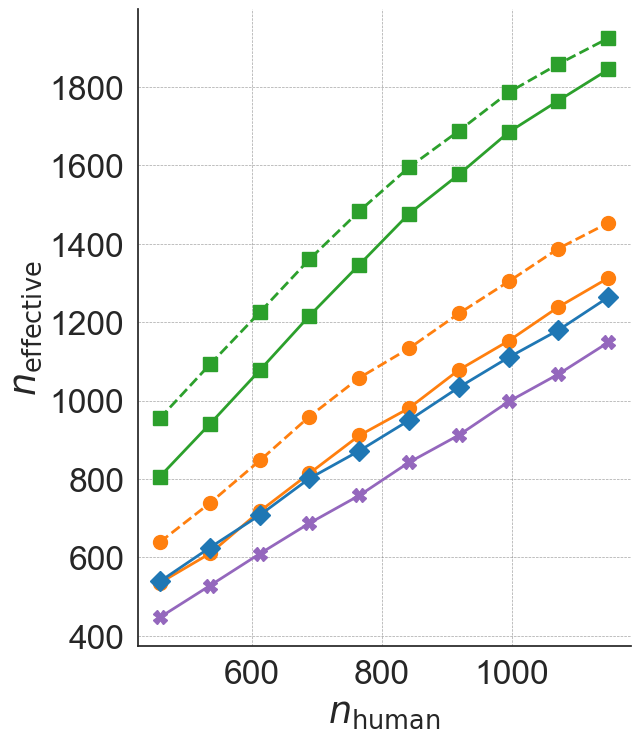

In [112]:
# effective sample size plot
#plot_eff_sample_size(df_all, "plots/test.pdf")
plot_eff_sample_size(df_all, "plots/seqstance_ESS.pdf")

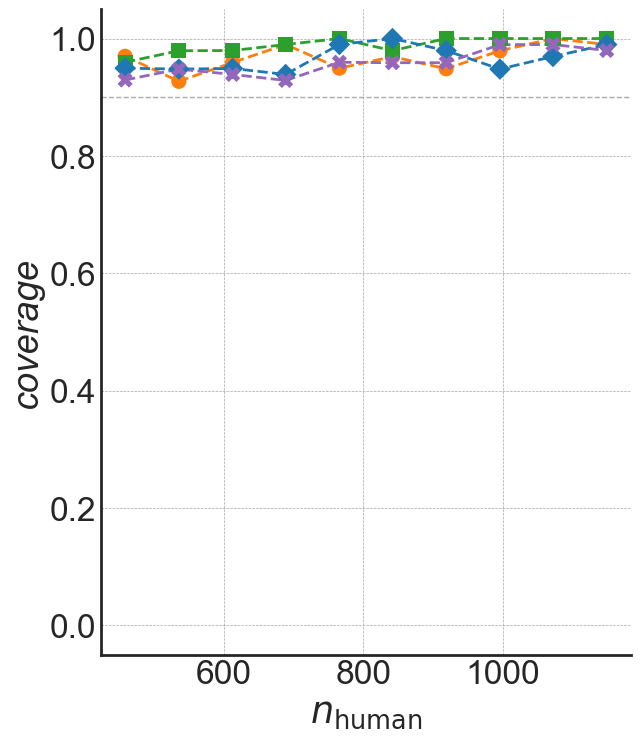

In [96]:
# coverage plot
plot_coverage(df_all, alpha, "plots/seqstance_coverage.pdf")

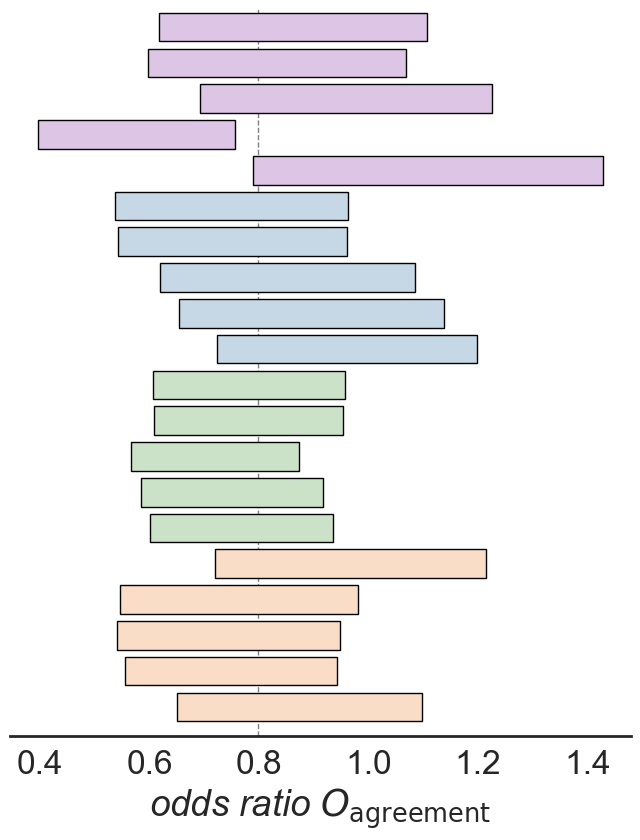

In [97]:
# sample intervals plot
plot_intervals(df_all, true_odds_ratio, num_trials, "odds ratio $O_{\mathrm{agreement}}$", "plots/seqstance_intervals.pdf", n_ind=5)